# Validazione del modello di classificazione "tracciabilita" vs regex

**Obiettivo.** Capire se il modello UmBERTo (binario `tracciabilita`/`altro`) che ha etichettato
`data/classified_technology_mapping/` (colonne `AI_LABEL`, `AI_CONFIDENCE`) e' **affidabile** o
**biased**, confrontandolo con la regex `traceability_worker.get_mask` e con **tre giudici
indipendenti** (lessicale, embedding, LLM locale).

## Avvertenza metodologica (leggere prima dei numeri)

Il **training set del modello e' stato costruito con la stessa regex** che qui usiamo come
riferimento. Ne consegue che:

- **La regex NON e' un gold standard indipendente.** Il confronto modello-vs-regex misura
  soprattutto due cose:
  1. **self-consistency** — il modello ha imparato a riprodurre la regex sui casi che la regex
     etichetta con sicurezza?
  2. **generalizzazione** — il modello trova casi di *significato* "tracciabilita" che la regex,
     essendo per costruzione molto specifica, non cattura?
- I **discordanti** sono quindi il cuore dell'analisi: se il modello dice `tracciabilita` dove la
  regex dice `altro`, sta **generalizzando bene** (ha colto il significato) o sta producendo
  **falsi positivi / si attiva su token spuri** (bias)? Solo un giudice esterno lo dirime.

## Sottigliezze del dato (impattano l'interpretazione)

- Il modello ha classificato **descrizioni uniche** (dedup su `DESCRIZIONE_PROGETTO`): `AI_LABEL` e'
  costante per descrizione. L'analisi principale e' quindi a livello di **descrizione unica**.
- I **negativi** del training sono stati filtrati con una regex *piu' semplice*
  (`tracciabil|rintracciabil|filiera|blockchain`) di `get_mask`: possibile **rumore di etichetta**.
- La regex valuta `TITOLO_PROGETTO` **OR** `DESCRIZIONE_PROGETTO` (lowercase): stesso criterio qui.

In [3]:
import os, sys, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# I worker sono nella stessa cartella del notebook: assicura l'import.
sys.path.insert(0, os.path.abspath("."))

INPUT_DIR = "../../data/classified_technology_mapping"
OUTPUT_DIR = "../../data/traceability/validation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

POS, NEG = "tracciabilita", "altro"

def save_table(df, path_noext):
    # Salva in parquet se possibile, altrimenti fallback a pickle. Ritorna il path scritto.
    try:
        p = path_noext + ".parquet"
        df.to_parquet(p, index=False)
        return p
    except Exception as e:
        p = path_noext + ".pkl"
        df.to_pickle(p)
        print(f"(parquet non disponibile: {e}; salvato pickle)")
        return p

FILES = sorted(glob.glob(os.path.join(INPUT_DIR, "reclassified_multiclass_aiuti_*.csv")))
# Hook di test: VALIDATION_MAX_FILES>0 usa solo gli N file piu' piccoli (smoke test rapido).
_LIMIT = int(os.environ.get("VALIDATION_MAX_FILES", "0"))
if _LIMIT > 0:
    FILES = sorted(FILES, key=os.path.getsize)[:_LIMIT]
    print(f"[TEST MODE] Uso solo {len(FILES)} file piu' piccoli.")
print(f"File classificati trovati: {len(FILES)}")
for f in FILES:
    print("  -", os.path.basename(f))

File classificati trovati: 12
  - reclassified_multiclass_aiuti_2014.csv
  - reclassified_multiclass_aiuti_2015.csv
  - reclassified_multiclass_aiuti_2016.csv
  - reclassified_multiclass_aiuti_2017.csv
  - reclassified_multiclass_aiuti_2018.csv
  - reclassified_multiclass_aiuti_2019.csv
  - reclassified_multiclass_aiuti_2020.csv
  - reclassified_multiclass_aiuti_2021.csv
  - reclassified_multiclass_aiuti_2022.csv
  - reclassified_multiclass_aiuti_2023.csv
  - reclassified_multiclass_aiuti_2024.csv
  - reclassified_multiclass_aiuti_2025.csv


## Sez. 1 — Costruzione della tabella di confronto (descrizioni uniche)

Per ogni file leggiamo a chunk solo le colonne utili, **deduplichiamo su `DESCRIZIONE_PROGETTO`**
(come il modello) e ricalcoliamo `REGEX_LABEL` con la **stessa** `get_mask` del training
(applicata a titolo OR descrizione). Usiamo `multiprocessing` sui 12 file (Ryzen 9 9900X), con la
logica isolata in `validation_worker.py` per evitare l'errore di pickling di Jupyter.

In [4]:
from multiprocessing import Pool, cpu_count
from validation_worker import process_file

_CACHE_PARQUET = os.path.join(OUTPUT_DIR, "comparison_unique.parquet")

def build_comparison(files):
    n_proc = min(len(files), cpu_count())
    print(f"Avvio Pool con {n_proc} processi...")
    with Pool(processes=n_proc) as pool:
        results = pool.map(process_file, files)
    parts = [df for _, df in results if len(df)]
    full = pd.concat(parts, ignore_index=True)
    # Dedup GLOBALE su descrizione: la stessa descrizione puo' comparire in piu' anni.
    # Teniamo la prima occorrenza (AI_LABEL e' comunque costante per descrizione).
    full = full.drop_duplicates(subset=["DESCRIZIONE_PROGETTO"]).reset_index(drop=True)
    return full

# Riusa la comparison table gia' salvata: evita di rileggere ~14GB a ogni riavvio del kernel.
# Per forzare la ricostruzione da CSV: metti REBUILD = True (o cancella il parquet).
REBUILD = False
if (not REBUILD) and _LIMIT == 0 and os.path.exists(_CACHE_PARQUET):
    comp = pd.read_parquet(_CACHE_PARQUET)
    print(f"Caricata comparison table dalla cache: {_CACHE_PARQUET}  (REBUILD=True per ricostruire)")
else:
    comp = build_comparison(FILES)
print(f"\nDescrizioni uniche totali: {len(comp):,}")

Caricata comparison table dalla cache: ../../data/traceability/validation/comparison_unique.parquet  (REBUILD=True per ricostruire)

Descrizioni uniche totali: 929,962


In [5]:
# Gestione dei non classificati (AI_LABEL NaN) -> esclusi dalla confusion matrix.
n_total = len(comp)
n_nan = int(comp["AI_LABEL"].isna().sum())
comp_valid = comp.dropna(subset=["AI_LABEL"]).copy()
comp_valid["AI_LABEL"] = comp_valid["AI_LABEL"].astype(str).str.strip()
comp_valid["AI_CONFIDENCE"] = pd.to_numeric(comp_valid["AI_CONFIDENCE"], errors="coerce")

print(f"Descrizioni uniche: {n_total:,}")
print(f"  - senza AI_LABEL (escluse): {n_nan:,} ({n_nan/n_total:.2%})")
print(f"  - valide per l'analisi:     {len(comp_valid):,}")
print("\nValori AI_LABEL:", comp_valid["AI_LABEL"].value_counts().to_dict())
print("Valori REGEX_LABEL:", comp_valid["REGEX_LABEL"].value_counts().to_dict())

# Salva la tabella di confronto per riuso.
_saved = save_table(comp_valid, os.path.join(OUTPUT_DIR, "comparison_unique"))
print(f"\nSalvato -> {_saved}")

Descrizioni uniche: 929,962
  - senza AI_LABEL (escluse): 0 (0.00%)
  - valide per l'analisi:     929,962

Valori AI_LABEL: {'altro': 884708, 'tracciabilita': 45254}
Valori REGEX_LABEL: {'altro': 927024, 'tracciabilita': 2938}

Salvato -> ../../data/traceability/validation/comparison_unique.parquet


## Sez. 2 — Confusion matrix & accordo (regex come *reference*)

Trattiamo `REGEX_LABEL` come riferimento (non gold) e misuriamo quanto il modello lo riproduce:
crosstab 2x2, precision/recall/F1 della classe `tracciabilita`, accuracy e **Cohen's kappa**.
Poi il **bias check**: confronto tra il *positive rate* del modello e quello della regex.

Confusion matrix (righe=regex, colonne=modello):


,modello=tracciabilita,modello=altro
regex=tracciabilita,2875,63
regex=altro,42379,884645


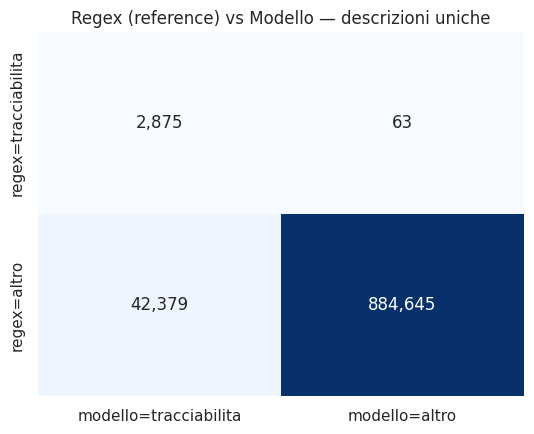

In [6]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             cohen_kappa_score, precision_recall_fscore_support)

y_ref = comp_valid["REGEX_LABEL"]
y_mod = comp_valid["AI_LABEL"]
labels = [POS, NEG]

cm = confusion_matrix(y_ref, y_mod, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"regex={l}" for l in labels],
                     columns=[f"modello={l}" for l in labels])
print("Confusion matrix (righe=regex, colonne=modello):")
display(cm_df)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Regex (reference) vs Modello — descrizioni uniche")
plt.tight_layout(); plt.show()

In [7]:
kappa = cohen_kappa_score(y_ref, y_mod)
acc = (y_ref.values == y_mod.values).mean()
p, r, f1, _ = precision_recall_fscore_support(y_ref, y_mod, labels=[POS], average=None)

reg_pos_rate = (y_ref == POS).mean()
mod_pos_rate = (y_mod == POS).mean()

print("=== Accordo modello vs regex (regex = reference) ===")
print(f"Accuracy globale ......... {acc:.4f}")
print(f"Cohen's kappa ............ {kappa:.4f}")
print(f"Precision (tracciabilita)  {p[0]:.4f}   <- dei positivi-modello, quanti sono anche regex+")
print(f"Recall (tracciabilita) ... {r[0]:.4f}   <- dei regex+, quanti li ritrova il modello")
print(f"F1 (tracciabilita) ....... {f1[0]:.4f}")
print()
print("=== Bias check: positive rate ===")
print(f"Positive rate REGEX ...... {reg_pos_rate:.4%}")
print(f"Positive rate MODELLO .... {mod_pos_rate:.4%}")
ratio = mod_pos_rate / reg_pos_rate if reg_pos_rate else float('nan')
print(f"Rapporto modello/regex ... {ratio:.2f}x")
if mod_pos_rate < 1e-4:
    print(">> ATTENZIONE: classe positiva quasi collassata (possibile bias verso 'altro').")
elif ratio > 3:
    print(">> Il modello etichetta molti piu' positivi della regex: over-trigger o generalizzazione (da verificare nei discordanti).")
else:
    print(">> Positive rate nello stesso ordine di grandezza della regex.")

=== Accordo modello vs regex (regex = reference) ===
Accuracy globale ......... 0.9544
Cohen's kappa ............ 0.1141
Precision (tracciabilita)  0.0635   <- dei positivi-modello, quanti sono anche regex+
Recall (tracciabilita) ... 0.9786   <- dei regex+, quanti li ritrova il modello
F1 (tracciabilita) ....... 0.1193

=== Bias check: positive rate ===
Positive rate REGEX ...... 0.3159%
Positive rate MODELLO .... 4.8662%
Rapporto modello/regex ... 15.40x
>> Il modello etichetta molti piu' positivi della regex: over-trigger o generalizzazione (da verificare nei discordanti).


In [8]:
# Breakdown per anno: stabilita' dell'accordo nel tempo.
by_year = (comp_valid
           .assign(agree=(y_ref.values == y_mod.values))
           .groupby("ANNO")
           .agg(n=("agree", "size"),
                accordo=("agree", "mean"),
                regex_pos=("REGEX_LABEL", lambda s: (s == POS).mean()),
                modello_pos=("AI_LABEL", lambda s: (s == POS).mean()))
           .reset_index())
display(by_year.style.format({"accordo": "{:.3f}", "regex_pos": "{:.4f}", "modello_pos": "{:.4f}"}))

,ANNO,n,accordo,regex_pos,modello_pos
0,2014,340,0.991,0.0000,0.0088
1,2015,796,0.990,0.0038,0.0138
2,2016,1065,0.968,0.0009,0.0329
3,2017,22448,0.968,0.0023,0.0341
4,2018,125232,0.825,0.0106,0.1846
5,2019,42041,0.943,0.0050,0.0617
6,2020,120784,0.979,0.0015,0.0227
7,2021,126878,0.988,0.0009,0.0129
8,2022,129874,0.986,0.0015,0.0153
9,2023,120906,0.985,0.0010,0.0162


## Sez. 3 — Analisi della confidenza

`AI_CONFIDENCE` e' la probabilita' softmax della classe predetta. Guardiamo come si distribuisce
nei quattro quadranti dell'accordo: un modello sano dovrebbe essere **meno confidente** dove
diverge dalla regex.

quadrant
B_concordi_neg        884645
C_solo_modello_pos     42379
A_concordi_pos          2875
D_solo_regex_pos          63
Name: count, dtype: int64


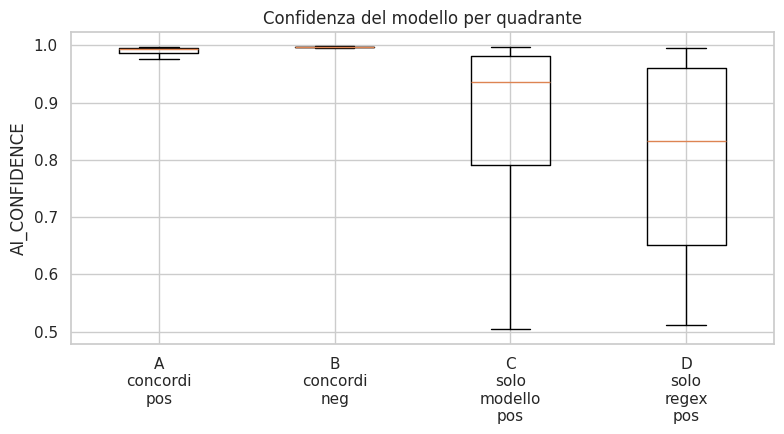

In [9]:
def quadrant(row):
    reg, mod = row["REGEX_LABEL"], row["AI_LABEL"]
    if reg == POS and mod == POS: return "A_concordi_pos"
    if reg == NEG and mod == NEG: return "B_concordi_neg"
    if reg == NEG and mod == POS: return "C_solo_modello_pos"
    return "D_solo_regex_pos"

comp_valid["quadrant"] = comp_valid.apply(quadrant, axis=1)
qcounts = comp_valid["quadrant"].value_counts()
print(qcounts)

fig, ax = plt.subplots(figsize=(8, 4.5))
order = ["A_concordi_pos", "B_concordi_neg", "C_solo_modello_pos", "D_solo_regex_pos"]
data = [comp_valid.loc[comp_valid.quadrant == q, "AI_CONFIDENCE"].dropna() for q in order]
ax.boxplot(data, labels=[q.replace("_", "\n") for q in order], showfliers=False)
ax.set_ylabel("AI_CONFIDENCE"); ax.set_title("Confidenza del modello per quadrante")
plt.tight_layout(); plt.show()

In [10]:
# Curva confidence-band -> tasso di accordo con la regex.
bands = pd.cut(comp_valid["AI_CONFIDENCE"], bins=np.linspace(0.5, 1.0, 11))
cal = (comp_valid.assign(agree=(y_ref.values == y_mod.values))
       .groupby(bands).agg(n=("agree", "size"), accordo=("agree", "mean")).reset_index())
display(cal)

,AI_CONFIDENCE,n,accordo
0,"(0.5, 0.55]",3354,0.518485
1,"(0.55, 0.6]",3466,0.514137
2,"(0.6, 0.65]",3660,0.536066
3,"(0.65, 0.7]",3841,0.539703
4,"(0.7, 0.75]",4476,0.549598
5,"(0.75, 0.8]",5038,0.545852
6,"(0.8, 0.85]",6449,0.568925
7,"(0.85, 0.9]",8762,0.594841
8,"(0.9, 0.95]",15814,0.628936
9,"(0.95, 1.0]",875102,0.978088


## Sez. 4 — Analisi dei discordanti (core)

- **Quadrante C** (`modello=tracciabilita`, `regex=altro`): *positivi solo-modello*. Generalizzazione
  o falsi positivi? E' il quadrante che decide se il modello ha colto il significato.
- **Quadrante D** (`regex=tracciabilita`, `modello=altro`): *miss del modello* su casi che la regex
  ritiene tracciabilita'.

Campioniamo in modo stratificato per fascia di confidenza per l'ispezione manuale e per i giudici.

In [11]:
def stratified_sample(df, n, conf_col="AI_CONFIDENCE", seed=RANDOM_STATE):
    # Campionamento stratificato per fascia di confidenza, robusto ai casi limite.
    if len(df) <= n:
        return df.copy()
    tmp = df.copy()
    try:
        tmp["_stratum"] = pd.qcut(tmp[conf_col].rank(method="first"),
                                  q=5, labels=False, duplicates="drop")
    except Exception:
        tmp["_stratum"] = 0
    tmp["_stratum"] = tmp["_stratum"].fillna(0)
    per = max(1, n // max(1, tmp["_stratum"].nunique()))
    picks = [g.sample(min(len(g), per), random_state=seed)
             for _, g in tmp.groupby("_stratum")]
    out = pd.concat(picks).head(n).drop(columns="_stratum")
    return out.reset_index(drop=True)

only_model = comp_valid[comp_valid.quadrant == "C_solo_modello_pos"].copy()
only_regex = comp_valid[comp_valid.quadrant == "D_solo_regex_pos"].copy()
print(f"Positivi solo-modello (C): {len(only_model):,}")
print(f"Miss del modello     (D): {len(only_regex):,}")

pd.set_option("display.max_colwidth", 140)
print("\n--- Campione C (solo modello dice tracciabilita) ---")
display(stratified_sample(only_model, 15)[["AI_CONFIDENCE", "TITOLO_PROGETTO", "DESCRIZIONE_PROGETTO"]])
print("\n--- Campione D (modello dice altro, regex dice tracciabilita) ---")
display(stratified_sample(only_regex, 15)[["AI_CONFIDENCE", "TITOLO_PROGETTO", "DESCRIZIONE_PROGETTO"]])

Positivi solo-modello (C): 42,379
Miss del modello     (D): 63

--- Campione C (solo modello dice tracciabilita) ---


,AI_CONFIDENCE,TITOLO_PROGETTO,DESCRIZIONE_PROGETTO
0,0.672762,Voucher early stage~COGNIMADE S.R.L.~AFFIANCAMENTO,ricerca nuovi clienti/partner su mercati di riferimento contatti con gli stessi verifica interesse ed eventuale trattativa commerciale...
1,0.531323,Titolo progetto: AUTOMATIZZAZIONE DEL PROCESSO PRODUTTIVO AZIENDALE CON EFFICIENTAMENTO ENERGETICO ED AMBIANTALE DELLO STESSO,L’investimento in nuovi macchinari aziendali consetirà come meglio dettagliato nei punti sottostanti di: - automatizzare ulteriormente ...
2,0.565224,Performance Management - I dati: lettura interpretazione ed analisi,CETOC -leader nella fornitura di servizi tecnico-amministrativi organizzativi e logistici nel campo Automotive- vuole dare continuità a...
3,0.831417,IL COMMERCIALISTA DIGITALE,IL PROGETTO PREVEDE LA MODERNIZZAZIONE DELL¿ORGANIZZAZIONE DEL LAVORO ATTRAVERSO L¿ACCESSO DA REMOTO AI SOFTWARE GESTIONALI ED AI DATI P...
4,0.848784,PIANO PER LO SVILUPPO STRATEGICO E OPERATIVO DEL MARKETING DIGITALE DI MEMOFLY,IL PROGETTO MIRA A POTENZIARE IL MARKETING DIGITALE DI MEMOFLY IL SOFTWARE DI GESTIONE APPUNTAMENTI PER I PROFESSIONISTI ATTRAVERSO UN...
5,0.872021,TECNICO PER L'INFORMATICA INDUSTRIALE CONTROLLO DIGITALE DEI PROCESSI PRODUTTIVI,Formazione continua - PROGETTI ESECUTIVI - 62656
6,0.942348,STRATEGIE DI DIGITAL MARKETING PER COMMERCIALIZZAZIONE IN ITALIA ED EUROPA DI TADÀ E DI TADÀPLAY,INTRAPRENDEREMO UN'ANALISI DEL MERCATO PER COMPRENDERE A FONDO IL NOSTRO PUBBLICO E LE DINAMICHE DELLA CONCORRENZA PER CREARE UNA STRATE...
7,0.911022,ACQUISTO DI N.1 MINI-ESCAVATORE CINGOLATO PER USO IN AMBITO EDILE DI DEMOLIZIONE. IL MACCHINARIO È IN OTTICA 4.0,IL PROGETTO RIGUARDA L'ACQUISTO DI N.1 MINI-ESCAVATORE CINGOLATO PER USO IN AMBITO EDILE DI DEMOLIZIONE. IL MACCHINARIO È IN OTTICA 4...
8,0.960287,Installazione di vending machine per distribuzione e prenotazione di prodotti farmaceutici.,Con il presente progetto si intende dotare la farmacia di un box esterno per la distribuzione e la prenotazione di prodotti farmaceutic...
9,0.982987,Miglioramento dell'organizzazione e dalle gestione clienti mediante implementazione gestionale su base software,Implementazione di un percorso di miglioramento organizzativo interno mediante rielaborazione delle procedure di lavoro per la gestione ...



--- Campione D (modello dice altro, regex dice tracciabilita) ---


,AI_CONFIDENCE,TITOLO_PROGETTO,DESCRIZIONE_PROGETTO
0,0.554365,SMART DE RISO,SMART DE RISO - INNOVAZIONE DI PROCESSO ALLINTERNO DEL SETTORE AGROALIMENTARE MEDIANTE LIMPIEGO DI UNA TECNOLOGIA AD HOC ABILITANTE ...
1,0.533656,Lamberti prointer,L’obiettivo del progetto di Lamberti è quello di rafforzare la sua presenza internazionale mediante l’identificazione di rivenditori e s...
2,0.564489,MIGLIORAMENTO EFFICIENZA AZIENDALE MODERNIZZAZIONE ORGANIZZAZIONE DEL LAVORO,MIGLIORAMENTO EFFICIENZA AZIENDALE MODERNIZZAZIONE ORGANIZZAZIONE DEL LAVORO TRAMITE ACQUISTO DI UN NUOVO SERVER E IMPIANTO INFORMATIC...
3,0.689776,ENDLESS S.R.L. SOCIETA' BENEFIT,attività dedicata alla raccolta di plastica e altri rifiuti marini mediante una catena del valore sostenibile e trasparente
4,0.699460,SIMCOVR SUPPORTO SPECIALISTICO PER IL PROGETTO NJORD,SUPPORTO NEL DISEGNARE UNA NUOVA ORGANIZZAZIONE A VANTAGGIO DI UNA FORMULA COMMERCIALE CHE SI DIFFERENZIA DA QUELLA TRADIZIONALE AZIENDA...
5,0.650356,Voucher advanced stage~MOLINO BENINI S.A.S DI RICCI LUCIANO~AFFIANCAMENTO,Molino Benini si farà affiancare da un TEM per iniziare un percorso di internazionalizzazione partendo dall¿identificazione dei possibil...
6,0.850655,FOOD BLOCKCHAIN E SICUREZZA ALIMENTARE: LEVE STRATEGICHE PER LA FILIERA CASEARIA,10748734
7,0.808823,Titolo progetto: PROMAC 4.0,?PROMAC 4.0? mira a potenziare la capacit? produttiva dello stabilimento di Manzano in risposta alla crescente domanda di beni strumen...
8,0.788746,INSTALLAZIONE NUOVO SERVER AZIENDALE E AGGIORNAMENTO LICENZE SOFTWARE,La società Stilgo Srl ha la necessità di installare un nuovo Server di rete per migliorare l'efficienza aziendale in cui installare un n...
9,0.966914,Ottimizzazione della Logistica della catena del Freddo attraverso lÂ¿interazione tra AI e IoT,Ottimizzazione della Logistica della catena del Freddo attraverso lÂ¿interazione tra AI e IoT


## Sez. 5 — Caratterizzazione lessicale TF-IDF (rilevamento bias)

Su cosa si "attiva" il modello nei positivi solo-modello? Confrontiamo i termini piu' discriminanti
dei *positivi solo-modello* (C) contro un campione di *negativi concordi* (B). Termini coerenti
(filiera, lotto, qr, provenienza, rintracciabilita...) indicano generalizzazione semantica; termini
spuri/generici indicano bias.

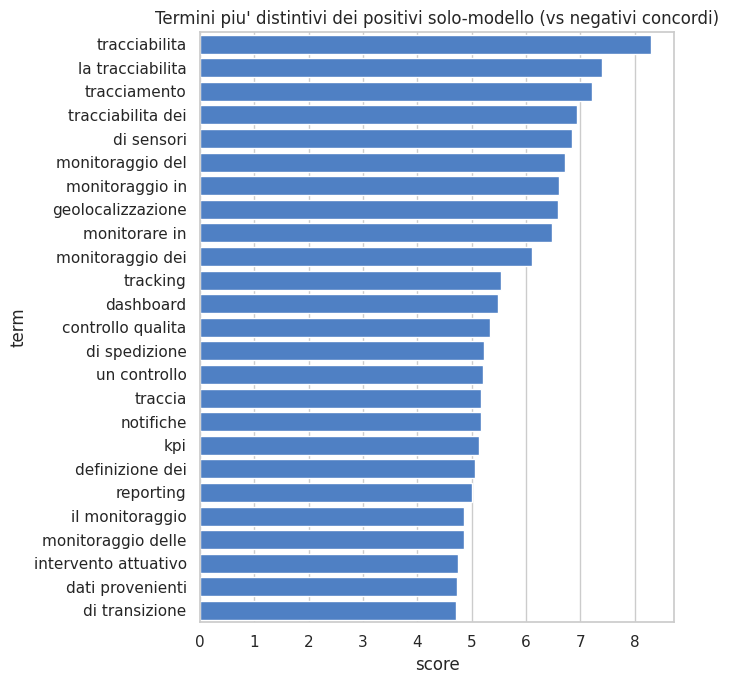

,term,score
0,tracciabilita,8.307620
1,la tracciabilita,7.403807
2,tracciamento,7.214111
3,tracciabilita dei,6.935902
4,di sensori,6.845719
5,monitoraggio del,6.725772
6,monitoraggio in,6.612206
7,geolocalizzazione,6.580069
8,monitorare in,6.479821
9,monitoraggio dei,6.109204


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

neg_sample = comp_valid[comp_valid.quadrant == "B_concordi_neg"].sample(
    min(len(only_model) if len(only_model) else 1, (comp_valid.quadrant == "B_concordi_neg").sum()),
    random_state=RANDOM_STATE)

def top_terms(pos_texts, neg_texts, k=25):
    corpus = list(pos_texts) + list(neg_texts)
    y = np.array([1]*len(pos_texts) + [0]*len(neg_texts))
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3,
                          sublinear_tf=True, strip_accents="unicode")
    X = vec.fit_transform(corpus)
    terms = np.array(vec.get_feature_names_out())
    mean_pos = np.asarray(X[y == 1].mean(axis=0)).ravel()
    mean_neg = np.asarray(X[y == 0].mean(axis=0)).ravel()
    logodds = np.log((mean_pos + 1e-6) / (mean_neg + 1e-6))
    idx = np.argsort(logodds)[::-1][:k]
    return pd.DataFrame({"term": terms[idx], "score": logodds[idx]})

if len(only_model) >= 10:
    tt = top_terms(only_model["DESCRIZIONE_PROGETTO"].fillna(""),
                   neg_sample["DESCRIZIONE_PROGETTO"].fillna(""))
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.barplot(data=tt, y="term", x="score", color="#3b7dd8", ax=ax)
    ax.set_title("Termini piu' distintivi dei positivi solo-modello (vs negativi concordi)")
    plt.tight_layout(); plt.show()
    display(tt)
else:
    print("Troppo pochi positivi solo-modello per un'analisi lessicale robusta.")

## Sez. 6 — Validatore embedding semantico (indipendente, GPU locale)

Segnale **indipendente** sia dalla regex sia dal modello: calcoliamo la similarita' coseno di ogni
descrizione discordante verso il **centroide** di frasi-seme "tracciabilita" e verso il centroide di
frasi-seme "altro" (via `sentence-transformers`, su GPU). `sem_score = sim_pos - sim_neg > 0` indica
significato di tracciabilita'.

In [13]:
try:
    from sentence_transformers import SentenceTransformer, util
    _ST_OK = True
except Exception as e:
    print("sentence-transformers non disponibile:", e)
    print("Installa con: pip install sentence-transformers")
    _ST_OK = False

In [14]:
SEEDS_POS = [
    "tracciabilita e rintracciabilita dei prodotti lungo la filiera",
    "sistema blockchain per la tracciabilita di filiera e la provenienza del prodotto",
    "etichettatura con QR code e RFID per tracciare i lotti e l'origine certificata",
    "passaporto digitale di prodotto per l'anticontraffazione della merce",
    "tracciamento della supply chain agroalimentare e sicurezza alimentare certificata",
]
SEEDS_NEG = [
    "corso di formazione professionale per dipendenti aziendali",
    "ristrutturazione edilizia e efficientamento energetico di un immobile",
    "acquisto di macchinari per la produzione industriale",
    "campagna di marketing e promozione turistica del territorio",
    "sviluppo di un sito web e app mobile per e-commerce",
]

def sem_scores(model, texts, batch=256):
    emb_pos = model.encode(SEEDS_POS, convert_to_tensor=True, normalize_embeddings=True)
    emb_neg = model.encode(SEEDS_NEG, convert_to_tensor=True, normalize_embeddings=True)
    cen_pos = emb_pos.mean(0, keepdim=True)
    cen_neg = emb_neg.mean(0, keepdim=True)
    emb = model.encode(list(texts), convert_to_tensor=True, normalize_embeddings=True,
                       batch_size=batch, show_progress_bar=True)
    sp = util.cos_sim(emb, cen_pos).cpu().numpy().ravel()
    sn = util.cos_sim(emb, cen_neg).cpu().numpy().ravel()
    return sp, sn

if _ST_OK:
    st_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device="cuda")
    # Valuta un campione ampio dei discordanti (C + D) per non saturare la GPU.
    disc = pd.concat([stratified_sample(only_model, 800), stratified_sample(only_regex, 800)]
                     ).reset_index(drop=True) if len(only_model)+len(only_regex) else comp_valid.head(0)
    if len(disc):
        sp, sn = sem_scores(st_model, disc["DESCRIZIONE_PROGETTO"].fillna(""))
        disc["sem_pos"], disc["sem_neg"] = sp, sn
        disc["sem_score"] = sp - sn
        disc["sem_pred"] = np.where(disc["sem_score"] > 0, POS, NEG)
        print("Embedding calcolati su", len(disc), "discordanti.")
    else:
        print("Nessun discordante da valutare.")
else:
    disc = comp_valid.head(0).copy()

Batches: 100%|██████████| 4/4 [00:00<00:00, 13.57it/s]

Embedding calcolati su 863 discordanti.


C_solo_modello_pos: n= 800 | sem_score medio=-0.068 | accordo embedding-modello=22.88%
D_solo_regex_pos: n=  63 | sem_score medio=-0.080 | accordo embedding-modello=73.02%

>> Positivi solo-modello confermati 'tracciabilita' dall'embedding: 22.88%
>> Correlazione (Spearman) AI_CONFIDENCE vs sem_score: +0.125


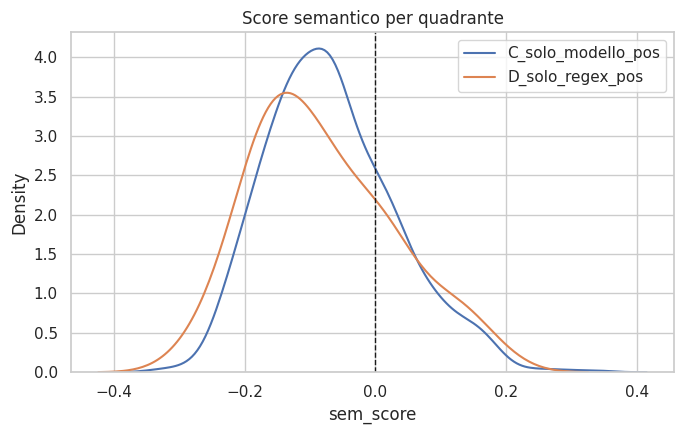

In [15]:
if _ST_OK and len(disc):
    for q, sub in disc.groupby("quadrant"):
        agree_sem = (sub["sem_pred"] == sub["AI_LABEL"]).mean()
        print(f"{q}: n={len(sub):4d} | sem_score medio={sub['sem_score'].mean():+.3f} | "
              f"accordo embedding-modello={agree_sem:.2%}")
    # Nei positivi solo-modello: quanti confermati dall'embedding come tracciabilita?
    c = disc[disc.quadrant == "C_solo_modello_pos"]
    if len(c):
        conf_rate = (c["sem_pred"] == POS).mean()
        print(f"\n>> Positivi solo-modello confermati 'tracciabilita' dall'embedding: {conf_rate:.2%}")
    # Correlazione confidenza modello <-> score semantico.
    if len(disc) > 5:
        rho = disc[["AI_CONFIDENCE", "sem_score"]].corr(method="spearman").iloc[0, 1]
        print(f">> Correlazione (Spearman) AI_CONFIDENCE vs sem_score: {rho:+.3f}")
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for q, sub in disc.groupby("quadrant"):
        sns.kdeplot(sub["sem_score"], label=q, ax=ax, fill=False)
    ax.axvline(0, color="k", ls="--", lw=1); ax.legend(); ax.set_title("Score semantico per quadrante")
    plt.tight_layout(); plt.show()

## Sez. 7 — Giudice LLM zero-shot locale (LM Studio, gpt-oss-20b)

Pseudo-gold indipendente. Usa l'endpoint OpenAI-compatibile di **LM Studio** (porta 1234) con output
strutturato (enum `tracciabilita`/`altro`) e strip del reasoning (`<think>`), via
`llm_judge_worker.py`. **Prerequisito:** avviare LM Studio con `gpt-oss-20b` e il server locale.
Se l'endpoint non risponde, la sezione fa **skip pulito**.

In [16]:
import importlib, llm_judge_worker as judge
importlib.reload(judge)

LLM_BASE_URL = "http://127.0.0.1:1234/v1"
LLM_MODEL = "openai/gpt-oss-20b"   # adatta al nome esposto da LM Studio
N_JUDGE_PER_QUADRANT = 120         # campione per quadrante discordante
N_CONTROL = 60                     # controllo sugli accordi

available = judge.ping(LLM_BASE_URL)
if available is None:
    print("LM Studio non raggiungibile su", LLM_BASE_URL, "-> sezione LLM saltata.")
    print("Avvia LM Studio + server locale con gpt-oss-20b, poi riesegui questa cella.")
    llm_df = None
else:
    print("LM Studio ok. Modelli disponibili (primi 5):", available[:5])

LM Studio ok. Modelli disponibili (primi 5): ['openai/gpt-oss-20b', 'google/gemma-4-12b-qat', 'qwen/qwen3.5-9b', 'text-embedding-nomic-embed-text-v1.5']


In [17]:
if available is not None:
    parts = []
    parts.append(stratified_sample(only_model, N_JUDGE_PER_QUADRANT).assign(source="C_solo_modello_pos"))
    parts.append(stratified_sample(only_regex, N_JUDGE_PER_QUADRANT).assign(source="D_solo_regex_pos"))
    ctrl_pos = comp_valid[comp_valid.quadrant == "A_concordi_pos"].sample(
        min(N_CONTROL, (comp_valid.quadrant == "A_concordi_pos").sum()), random_state=RANDOM_STATE).assign(source="A_concordi_pos")
    ctrl_neg = comp_valid[comp_valid.quadrant == "B_concordi_neg"].sample(
        min(N_CONTROL, (comp_valid.quadrant == "B_concordi_neg").sum()), random_state=RANDOM_STATE).assign(source="B_concordi_neg")
    parts += [ctrl_pos, ctrl_neg]
    llm_df = pd.concat(parts, ignore_index=True)

    records = [{"titolo": t, "descrizione": d}
               for t, d in zip(llm_df["TITOLO_PROGETTO"].fillna(""), llm_df["DESCRIZIONE_PROGETTO"].fillna(""))]
    print(f"Invio {len(records)} record al giudice LLM (con cache su disco)...")
    llm_df["LLM_LABEL"] = judge.judge_batch(records, model=LLM_MODEL, base_url=LLM_BASE_URL, concurrency=4)

    errs = llm_df["LLM_LABEL"].astype(str).str.startswith("error").sum()
    print(f"Completato. Errori LLM: {errs}/{len(llm_df)}")
    print(llm_df["LLM_LABEL"].value_counts().to_dict())

Invio 303 record al giudice LLM (con cache su disco)...
Completato. Errori LLM: 0/303
{'altro': 291, 'tracciabilita': 12}


In [18]:
if available is not None and llm_df is not None:
    ok = llm_df[~llm_df["LLM_LABEL"].astype(str).str.startswith("error")].copy()
    print("=== Confronto a 3 vie (regex vs modello vs LLM) ===\n")
    for src, sub in ok.groupby("source"):
        agree_mod = (sub["LLM_LABEL"] == sub["AI_LABEL"]).mean()
        agree_reg = (sub["LLM_LABEL"] == sub["REGEX_LABEL"]).mean()
        print(f"{src}: n={len(sub):3d} | LLM==modello={agree_mod:.2%} | LLM==regex={agree_reg:.2%}")

    c = ok[ok.source == "C_solo_modello_pos"]
    d = ok[ok.source == "D_solo_regex_pos"]
    if len(c):
        print(f"\n>> Positivi solo-modello confermati dall'LLM come 'tracciabilita': "
              f"{(c['LLM_LABEL']==POS).mean():.2%}  (precisione del modello OLTRE la regex)")
    if len(d):
        print(f">> Miss del modello che l'LLM conferma 'tracciabilita' (regex aveva ragione): "
              f"{(d['LLM_LABEL']==POS).mean():.2%}")

=== Confronto a 3 vie (regex vs modello vs LLM) ===

A_concordi_pos: n= 60 | LLM==modello=13.33% | LLM==regex=13.33%
B_concordi_neg: n= 60 | LLM==modello=100.00% | LLM==regex=100.00%
C_solo_modello_pos: n=120 | LLM==modello=0.83% | LLM==regex=99.17%
D_solo_regex_pos: n= 63 | LLM==modello=95.24% | LLM==regex=4.76%

>> Positivi solo-modello confermati dall'LLM come 'tracciabilita': 0.83%  (precisione del modello OLTRE la regex)
>> Miss del modello che l'LLM conferma 'tracciabilita' (regex aveva ragione): 4.76%


## Sez. 8 — Sintesi, verdetto ed export

Combiniamo i segnali sui discordanti (embedding + LLM dove disponibile) per stimare se i *positivi
solo-modello* sono generalizzazione corretta o falsi positivi, ed emettiamo un verdetto sul bias.
Esportiamo la tabella dei discordanti con tutti gli score e un riepilogo JSON.

In [19]:
summary = {
    "n_descrizioni_uniche": int(n_total),
    "n_non_classificate": int(n_nan),
    "n_valide": int(len(comp_valid)),
    "accuracy_vs_regex": float(acc),
    "cohen_kappa": float(kappa),
    "precision_pos_vs_regex": float(p[0]),
    "recall_pos_vs_regex": float(r[0]),
    "f1_pos_vs_regex": float(f1[0]),
    "positive_rate_regex": float(reg_pos_rate),
    "positive_rate_modello": float(mod_pos_rate),
    "n_solo_modello_pos": int(len(only_model)),
    "n_solo_regex_pos": int(len(only_regex)),
}

# Merge degli score dei giudici sui discordanti, dove calcolati.
scored = comp_valid[comp_valid.quadrant.isin(["C_solo_modello_pos", "D_solo_regex_pos"])].copy()
if _ST_OK and len(disc):
    scored = scored.merge(disc[["DESCRIZIONE_PROGETTO", "sem_pos", "sem_neg", "sem_score", "sem_pred"]],
                          on="DESCRIZIONE_PROGETTO", how="left")
    summary["embedding_confirm_solo_modello_pos"] = float(
        (disc[disc.quadrant=="C_solo_modello_pos"]["sem_pred"] == POS).mean()) if (disc.quadrant=="C_solo_modello_pos").any() else None
try:
    if available is not None and llm_df is not None:
        scored = scored.merge(llm_df[["DESCRIZIONE_PROGETTO", "LLM_LABEL"]].drop_duplicates("DESCRIZIONE_PROGETTO"),
                              on="DESCRIZIONE_PROGETTO", how="left")
        _c = llm_df[(llm_df.source=="C_solo_modello_pos") & (~llm_df.LLM_LABEL.astype(str).str.startswith("error"))]
        summary["llm_confirm_solo_modello_pos"] = float((_c["LLM_LABEL"]==POS).mean()) if len(_c) else None
except NameError:
    pass

scored.to_csv(os.path.join(OUTPUT_DIR, "discordant_scored.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "validation_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nSalvati: discordant_scored.csv, validation_summary.json in", OUTPUT_DIR)

{
  "n_descrizioni_uniche": 929962,
  "n_non_classificate": 0,
  "n_valide": 929962,
  "accuracy_vs_regex": 0.9543615760643983,
  "cohen_kappa": 0.11405782047153623,
  "precision_pos_vs_regex": 0.06353029566447164,
  "recall_pos_vs_regex": 0.9785568413886998,
  "f1_pos_vs_regex": 0.1193144090305445,
  "positive_rate_regex": 0.0031592688733518143,
  "positive_rate_modello": 0.04866220340185943,
  "n_solo_modello_pos": 42379,
  "n_solo_regex_pos": 63,
  "embedding_confirm_solo_modello_pos": 0.22875,
  "llm_confirm_solo_modello_pos": 0.008333333333333333
}

Salvati: discordant_scored.csv, validation_summary.json in ../../data/traceability/validation


In [20]:
# --- Verdetto automatico (euristico) ---
print("=== VERDETTO ===\n")
if mod_pos_rate < 1e-4:
    print("BIAS: la classe 'tracciabilita' e' quasi collassata. Il modello NON e' affidabile.")
else:
    emb_conf = summary.get("embedding_confirm_solo_modello_pos")
    llm_conf = summary.get("llm_confirm_solo_modello_pos")
    print(f"Accordo strutturale con la regex (kappa): {kappa:.3f}")
    print(f"Positive rate modello/regex: {ratio:.2f}x")
    if emb_conf is not None:
        print(f"Positivi solo-modello confermati dall'embedding: {emb_conf:.1%}")
    if llm_conf is not None:
        print(f"Positivi solo-modello confermati dall'LLM:       {llm_conf:.1%}")
    signals = [x for x in [emb_conf, llm_conf] if x is not None]
    if signals:
        mean_conf = np.mean(signals)
        if mean_conf >= 0.6:
            print("\n>> Il modello GENERALIZZA: i positivi extra-regex sono in larga parte veri.")
        elif mean_conf <= 0.3:
            print("\n>> Il modello sembra OVER-TRIGGER: molti positivi extra-regex sono falsi (bias lessicale).")
        else:
            print("\n>> Comportamento MISTO: parte generalizzazione, parte rumore. Serve soglia di confidenza.")
    else:
        print("\n>> Avvia i giudici (embedding/LLM) per un verdetto sui discordanti.")

=== VERDETTO ===

Accordo strutturale con la regex (kappa): 0.114
Positive rate modello/regex: 15.40x
Positivi solo-modello confermati dall'embedding: 22.9%
Positivi solo-modello confermati dall'LLM:       0.8%

>> Il modello sembra OVER-TRIGGER: molti positivi extra-regex sono falsi (bias lessicale).


## Sez. 9 — Raccomandazioni

- **Se il modello generalizza** (giudici confermano i positivi solo-modello): la regex sottostima la
  tracciabilita'; considerare il modello come estrattore primario con una **soglia di confidenza**
  operativa tarata sulla curva di calibrazione (Sez. 3).
- **Se over-trigger**: rifinire il training — i **negativi** erano filtrati con una regex piu' debole
  (`tracciabil|rintracciabil|filiera|blockchain`), quindi contenevano rumore; ri-etichettare i
  negativi con `get_mask` completa e/o con il **gold LLM** e ri-addestrare.
- **Miss del modello (quadrante D)**: ispezionare i casi dove regex+LLM concordano su `tracciabilita`
  ma il modello dice `altro`; sono errori di *recall* da aggiungere al training.
- **Prossimo passo**: usare `discordant_scored.csv` (con `sem_score` e `LLM_LABEL`) come nuovo set di
  supervisione per un secondo ciclo di fine-tuning, riducendo la dipendenza circolare dalla regex.